<a href="https://colab.research.google.com/github/shashwat12jha/Exploratory-Project/blob/main/Codechange1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing Libraries


In [1]:
!pip install shapely pandas numpy scipy matplotlib

In [2]:
import pandas as pd
import numpy as np
from shapely.geometry import LineString, Point
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

In [15]:
import pandas as pd

data = {
    "Track ID":[1,1,1,1,1, 2,2,2,2,2],
    "Frame":[1,2,3,4,5, 2,3,4,5,6],
    "X Coordinate":[50,80,110,140,170, 110,110,110,110,110],
    "Y Coordinate":[110,110,110,110,110, 50,80,110,140,170],
    "Speed":[10]*10,
    "Class":["car"]*10
}

df = pd.DataFrame(data)
df

,Track ID,Frame,X Coordinate,Y Coordinate,Speed,Class
0,1,1,50,110,10,car
1,1,2,80,110,10,car
2,1,3,110,110,10,car
3,1,4,140,110,10,car
4,1,5,170,110,10,car
5,2,2,110,50,10,car
6,2,3,110,80,10,car
7,2,4,110,110,10,car
8,2,5,110,140,10,car
9,2,6,110,170,10,car


In [16]:
trajectories = {
    track_id: group.sort_values("Frame")
    for track_id, group in df.groupby("Track ID")
}

In [17]:
##smoothening the trajectory
def smooth_trajectory(traj):

    x = traj["X Coordinate"].values
    y = traj["Y Coordinate"].values

    if len(x) >= 5:
        x = savgol_filter(x, 5, 2)
        y = savgol_filter(y, 5, 2)

    return list(zip(x,y))

In [18]:
paths = {}

for track_id, traj in trajectories.items():

    smoothed = smooth_trajectory(traj)

    if len(smoothed) > 1:
        paths[track_id] = LineString(smoothed)

In [19]:
intersections = []

track_ids = list(paths.keys())

for i in range(len(track_ids)):
    for j in range(i+1,len(track_ids)):

        id1 = track_ids[i]
        id2 = track_ids[j]

        line1 = paths[id1]
        line2 = paths[id2]

        if line1.intersects(line2):

            point = line1.intersection(line2)

            intersections.append({
                "Track ID 1":id1,
                "Track ID 2":id2,
                "X":point.x,
                "Y":point.y
            })

intersections_df = pd.DataFrame(intersections)
intersections_df

,Track ID 1,Track ID 2,X,Y
0,1,2,110.0,110.0


In [20]:
##CALCULATING Post Encroachment Time
FPS = 30

def compute_pet(track1, track2, point):

    traj1 = trajectories[track1]
    traj2 = trajectories[track2]

    traj1["dist"] = np.sqrt((traj1["X Coordinate"]-point.x)**2 +
                            (traj1["Y Coordinate"]-point.y)**2)

    traj2["dist"] = np.sqrt((traj2["X Coordinate"]-point.x)**2 +
                            (traj2["Y Coordinate"]-point.y)**2)

    t1 = traj1.loc[traj1["dist"].idxmin(),"Frame"]
    t2 = traj2.loc[traj2["dist"].idxmin(),"Frame"]

    pet = abs(t1-t2)/FPS

    return pet

In [21]:
pets = []

for _,row in intersections_df.iterrows():

    point = Point(row["X"],row["Y"])

    pet = compute_pet(row["Track ID 1"],row["Track ID 2"],point)

    pets.append(pet)

intersections_df["PET"] = pets
intersections_df

,Track ID 1,Track ID 2,X,Y,PET
0,1,2,110.0,110.0,0.033333


In [22]:
#TTC

In [23]:
def compute_ttc(distance, v1, v2):

    relative_speed = abs(v1-v2)

    if relative_speed == 0:
        return np.inf

    return distance/relative_speed

In [24]:
##example
distance = 10
speed1 = 12
speed2 = 8

print("TTC:",compute_ttc(distance,speed1,speed2))

TTC: 2.5


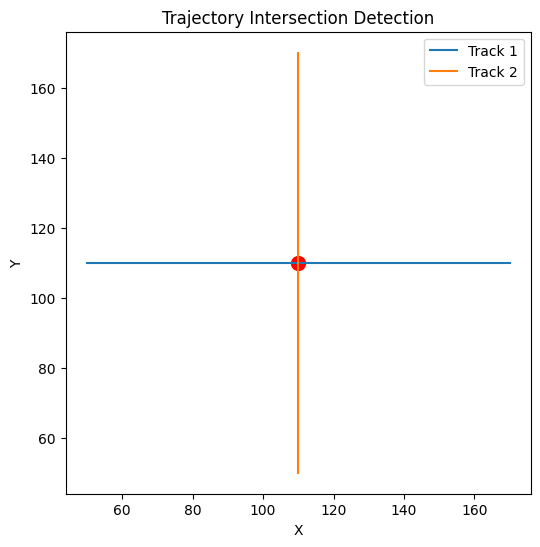

In [25]:
plt.figure(figsize=(6,6))

for track_id, traj in trajectories.items():

    plt.plot(traj["X Coordinate"],traj["Y Coordinate"],label=f"Track {track_id}")

for _,row in intersections_df.iterrows():

    plt.scatter(row["X"],row["Y"],color="red",s=100)

plt.legend()
plt.title("Trajectory Intersection Detection")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [26]:
dangerous = intersections_df[intersections_df["PET"] < 3]

dangerous

,Track ID 1,Track ID 2,X,Y,PET
0,1,2,110.0,110.0,0.033333
